# 1 - Process MS MARCO dataset

* Project website: https://microsoft.github.io/msmarco/
* Download queries only (18Mb) - we are not interested in candidate documents - and unzip - https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz

## Download MS Marco dataset

In [1]:
!wget https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz

--2026-02-03 22:55:42--  https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz
Resolving msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)... 57.150.146.100
Connecting to msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)|57.150.146.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18882551 (18M) [application/gzip]
Saving to: ‘queries.tar.gz’

queries.tar.gz      100%[===================>]  18.01M   166KB/s    in 40s     

2026-02-03 22:56:23 (463 KB/s) - ‘queries.tar.gz’ saved [18882551/18882551]



In [37]:
import pandas as pd
import requests
import json
import datetime

# For progress bars
from tqdm.notebook import tqdm
tqdm.pandas()

In [38]:
%%time

# Combine dev, eval, and train into a single set

queries = pd.concat([
    pd.read_csv('queries/queries.dev.tsv', sep='\t', names=['query_id', 'query_text']),
    pd.read_csv('queries/queries.eval.tsv', sep='\t', names=['query_id', 'query_text']),
    pd.read_csv('queries/queries.train.tsv', sep='\t', names=['query_id', 'query_text']),
]).drop_duplicates('query_id').drop_duplicates('query_text')

CPU times: user 443 ms, sys: 65.1 ms, total: 508 ms
Wall time: 547 ms


In [39]:
queries.shape

(1010916, 2)

In [64]:
queries.query('query_text == "cost of living in turkmenistan"')

,query_id,query_text
53904,105311,cost of living in turkmenistan


In [6]:
queries.query_text.sample(20).tolist()

['mouth breather medicine for cold',
 'where is clovelly',
 'tax consequence change custodian',
 'what type of food do teenagers eat',
 'things to do in the mesa az area',
 'how to raise credit',
 'here is the detail or here are',
 'what elements will darken lawn',
 'where is the original winnie the pooh located',
 'what is the purpose of ncua lending regulations',
 'weather in cappadocia turkey',
 'what is a mouth exostosis',
 'largest hydroelectric dam in us',
 'where does the name el nino originate from',
 'what is a slurry pump used for',
 'how does heat affect egg laying',
 'how many paper mills are in virginia',
 'what is the national defense act of 1916',
 'what causes a dog to pass blood',
 "what's a hillbilly?"]

In [7]:
queries.query_text.str.contains('near').mean()

0.0012226535142385718

<Axes: >

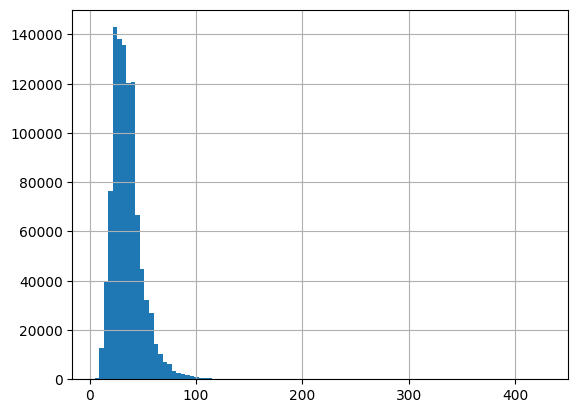

In [8]:
queries.query_text.str.len().hist(bins=100)

In [6]:
queries[queries.query_text.str.len().gt(100) & queries.query_text.str.len().lt(200)].query_text.tolist()

[') what is the acceleration of the upper block? (indicate the direction with the sign of your answer.)',
 '. What was the movement called humanism? How did it originate, and what were its main characteristics?',
 'what is offered to employees who have been determined to be at risk for exposure to bloodborne pathogens?',
 'who says she was looking into my eyes with that way she had of looking that made you wonder whether she really saw out of her own eyes.',
 'Although the Civil Rights Act of 1964 was the most comprehensive civil rights legislation ever considered it does not',
 'An infection that is spread by the blood or lymphatic system to large portions of the body is called:',
 'what is most commonly used financial performance measure when evaluating an organizations performance',
 'what is meant by the phrase social construction of disability? what are the implications of this term for assessment and identification of disabilities?',
 'what is meant by solution concentration and 

In [7]:
queries.to_csv('interim/queries.csv.zip', index=False)

## Precompute embeddings for all queries
- Use `BAAI/bge-small-en-v1.5` for all embeddings
- We'll sample points from the whole vector space so that we have a diverse set of examples

In [2]:
import numpy as np
from sentence_transformers import SentenceTransformer

/Users/ilya/miniconda3/lib/python3.11/site-packages/gunicorn/util.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [39]:
queries = pd.read_csv('interim/queries.csv.zip')

In [40]:
model = SentenceTransformer("BAAI/bge-small-en-v1.5")

In [ ]:
query_emb = model.encode(
    queries.query_text.tolist(),
    batch_size=32,
    normalize_embeddings=True, # cosine‑ready vectors
    show_progress_bar=True
) # --> outputs numpy array shape (len(queries), 384)

In [19]:
np.save('interim/query_emb.npy', query_emb)

## Sample points to cover the whole vector space
- We know from the MS Marco paper that very roughly 5% of queries are labelled as Location so we would need ca 10K points to get approx 500 positive (geospatial) queries
- But our extended definition is actually broader; back-of-the-envelope estimate showed it's closer to 10-20% so let's sample 5k points instead

In [ ]:
from sklearn.cluster import kmeans_plusplus

In [4]:
xb = np.load("interim/query_emb.npy").astype('float32')  # (n_queries, 384)

In [ ]:
centroids, sample_inds = kmeans_plusplus(xb, n_clusters=5000, random_state=0)

In [8]:
np.save('interim/sample_inds.5k.npy', sample_inds)

# Use LLM for weak labelling: ask Llama to distinguish geospatial from non-geospatial

- Use Llama 3.1 to classify sampled queries
- We will manually review the results but the goal is to build a collection of 500 positive and 500 negative samples
- This collection will then be used in SetFit to build a classifier

Definitions of geographical/geospatial (we use both):

- [Kefalidis et al's (2024)](https://www.sciencedirect.com/science/article/pii/S1569843224005594?via%3Dihub): *"we define a question as geospatial if it requires qualitative or quantitative geographic knowledge to be answered"*
  - "Qualitative geographic knowledge can be captured by qualitative binary relations between the geometries of features. Qualitative geospatial data can be expressed as a property of an entity or an explicit assertion."
  - "Quantitative geographic knowledge is, usually, represented using geometries (e.g., points, lines and polygons on the Cartesian plane). In particular, quantitative geospatial data can be expressed by a property of an entity which has value a geometry (latitude/longitude pair or polygon)."
- [Mai's (2021)](https://agile-giss.copernicus.org/articles/2/8/2021/) *"we define geographic questions as questions that involve geographic entities (e.g., Los Angeles, Eastern Sierra), geographic concepts (e.g., feature types such as Building, City, State), or spatial relations (e.g. near to, north of, between) as parts of the natural language questions. Note that this definition is rather broad compared to related notions such as geo-analytical questions (Scheider et al., 2020) which require geo-analytical workflows (in GIS) to answer them."*

In [9]:
queries = pd.read_csv('interim/queries.csv.zip')
sample_inds = np.load('interim/sample_inds.5k.npy')

In [10]:
def ask_llm(prompt, limit=9999, temp=0):
    """
    Sends the `prompt` to the LLM running locally via Ollama.
    Temperature = 0 / fixed seed will get consistent output between runs.
    Works much faster for shorter limits, so setting to 1
    for simple True/False judgments.
    """
    response = requests.post(
        url='http://localhost:11434/api/generate',
        json={
            'model': 'llama3.1',
            'prompt': prompt,
            'stream': False,
            'options': {
                'temperature': temp,
                # 'seed': 42, # remove to allow for randomness
                'num_predict': limit
            }
        }
    )

    try:
        return json.loads(response.text).get('response').strip()
    except:
        return ''



def is_geospatial(query_text, temp=0, n_runs=1):
    
    prompt = f"""Classify the search query as geospatial (true) or not (false).

A query is geospatial if it requires qualitative or quantitative geographic
knowledge of Earth-bound features to be answered. This is usually the case if the query involves:
- A geographic entity (named place on Earth: city, country, river, POI, address)
- A geographic concept (place type: city, lake, mountain, park, building)
- A spatial relation (near, within, north of, between, borders, crosses, distance)

Non-geospatial: anatomical, microscopic, astronomical, fictional, or abstract
'where' questions; queries needing no geographic knowledge.

Output only: true or false.

Examples:
  * How far is Brighton from London -> true
  * what does square from greece mean -> false
  * Capital of France -> true
  * What does 'Dutch courage' mean -> false
  * Population of Piraeus -> true
  * Where is the epimysium found -> false
  * Restaurants near Hyde Park -> true
  * Where did the name Missouri come from -> false
  * Where does Paris Hilton live -> true
  * What is a river -> false
  * What city is Ebright Azimuth in -> true
  * is the water underneath a hurricane calm -> false
  * how many state are in the us -> true
  * Where is the SSID -> false
  * where are new franchises needed -> true
  * which side is the us flag put -> false
  * what languages are spoken in israel -> true
  * Where is Hogwarts -> false
  * most western point in portugal -> true
  * What is Greek yoghurt -> false

Query: '{query_text.strip()}'
Answer:
    """

    answers = []
    for i in range(n_runs):
        answers.append( ask_llm(prompt, 1, temp).lower() )
        
    return answers

In [12]:
is_geospatial('where is superbowl')

['true']

In [14]:
is_geospatial('where is the money')

['false']

In [17]:
subset = queries.iloc[sample_inds].copy()

In [18]:
%%time

subset['is_geospatial'] = subset.query_text.progress_apply(
    lambda q: is_geospatial(q, 0.3, n_runs=5)
)

  0%|          | 0/5000 [00:00<?, ?it/s]

CPU times: user 1min 18s, sys: 25.9 s, total: 1min 44s
Wall time: 1h 11min


In [19]:
subset['is_geospatial_count'] = subset.is_geospatial.apply(
    lambda li: len( [x for x in li if x == 'true'] )
)

In [20]:
subset.is_geospatial_count.value_counts()

is_geospatial_count
0    4372
5     547
1      32
2      19
4      17
3      13
Name: count, dtype: int64

In [21]:
subset.to_excel(
    f'interim/is_geospatial_20260428.xlsx',
    index=False
)

## Plots

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
manual_verif = pd.read_excel('interim/is_geospatial_20260428_edits.xlsx')

In [34]:
# Get true/false positives
manual_verif.query('is_geospatial_count >0').is_geospatial_human_check.value_counts()

is_geospatial_human_check
1.0    561
0.0     67
Name: count, dtype: int64

In [35]:
# Get true/false negatives
manual_verif.query('is_geospatial_count == 0').is_geospatial_human_check.value_counts()

is_geospatial_human_check
0.0    565
1.0      7
Name: count, dtype: int64

In [9]:
majority_voting_data = (
    pd.read_excel('interim/is_geospatial_20260428_edits.xlsx')
    .query('is_geospatial_count > 0')
    .groupby('is_geospatial_count')
    .agg({'is_geospatial_human_check': ['count', 'mean']})
    ['is_geospatial_human_check']
)

majority_voting_data['percent_true'] = majority_voting_data['mean'] * 100

majority_voting_data

,count,mean,percent_true
is_geospatial_count,,,
1,32,0.531250,53.125000
2,19,0.578947,57.894737
3,13,0.846154,84.615385
4,17,0.470588,47.058824
5,547,0.939671,93.967093


In [27]:
# How many received at least 1 geospatial vote from an LLM?
majority_voting_data['count'].sum()

628

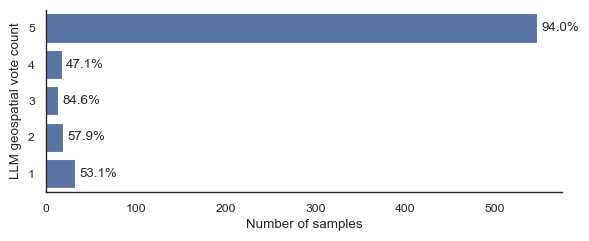

In [24]:
# Minimal style
sns.set_theme(style='white', context='paper')

fig, ax = plt.subplots(figsize=(6, 2.5))

# Bar plot
sns.barplot(
    data=majority_voting_data,
    y='is_geospatial_count',
    x='count',
    ax=ax,
    orient='h'
)

# Percentage annotations
for i, row in majority_voting_data.iterrows():
    ax.text(
        row['count'] + 5,
        i-1,
        f"{row['percent_true']:.1f}%",
        ha='left',
        va='center'
    )

# Labels (no title – use caption in paper)
ax.set_ylabel('LLM geospatial vote count')
ax.set_xlabel('Number of samples')
ax.invert_yaxis()

sns.despine()
plt.tight_layout()

# For publication export:
plt.savefig('output/weak-labels-1-to-5.pdf', bbox_inches='tight')
plt.show()

In [11]:
# Let's look at the edits
data = (
    pd.read_excel('interim/is_geospatial_20260428_edits.xlsx')
    .dropna(subset=['is_geospatial_human_check'])
    .assign(
        is_geospatial_human_check=lambda df_: df_.is_geospatial_human_check.astype(bool)
    )
    .query('is_geospatial_count >0 & not is_geospatial_human_check')
)

In [12]:
data

,query_id,query_text,is_geospatial,is_geospatial_count,is_geospatial_human_check,note
7,486522,reference letter to an apartment,"['false', 'true', 'false', 'false', 'true']",2,False,NaN
112,401014,is a square perpendicular,"['true', 'true', 'true', 'false', 'true']",4,False,NaN
201,108182,cost per ft2 paving,"['true', 'true', 'true', 'true', 'true']",5,False,No geo
243,490510,routing number tools lyons,"['true', 'true', 'true', 'true', 'true']",5,False,I don't know what this is
251,255444,how long does it take to be a year on earth,"['true', 'true', 'true', 'true', 'true']",5,False,NaN
...,...,...,...,...,...,...
4563,362208,how to get perimeter when you only have the area,"['true', 'true', 'true', 'true', 'true']",5,False,general math formula / geometry
4599,722760,what is bc,"['true', 'true', 'true', 'true', 'true']",5,False,Ambiguous/ could be time aka AD/BC?
4802,502992,state license board number for contractors,"['true', 'true', 'true', 'true', 'true']",5,False,Not an attribute for a particular POI / not fo...
4824,859828,what is used to indicate a search term can be ...,"['true', 'true', 'true', 'true', 'true']",5,False,no geo
